# ECE501 Digital Image Processing
## Project 8 – Vehicle Orientation Estimation Using Conventional Image Processing

### Week 2: Dataset Preparation and Vehicle Crop Extraction

This notebook documents the Week-2 implementation for the vehicle orientation estimation project using the DRASHTI-HaOBB dataset.

The objectives of this stage are:

1. Connect the Google Drive dataset workspace to Google Colab.
2. Read and understand the original DRASHTI-HaOBB annotations.
3. Parse the Oriented Bounding Box (OBB) coordinates, vehicle class, difficulty level, and heading angle.
4. Select a small and representative set of vehicle samples for initial development.
5. Match the selected annotations with their corresponding original images.
6. Visualize the OBB annotations on the original images.
7. Extract vehicle crops while preserving the original vehicle orientation.
8. Prepare the ground-truth heading and orientation information for later orientation estimation.

The orientation-estimation algorithm itself will be developed in the next stage of the project.

## 1. Python Environment and Required Libraries

The following cell installs and imports the Python libraries required for the Week-2 dataset-processing pipeline.

The implementation uses Python together with NumPy, OpenCV, Pandas, Matplotlib, and supporting utilities. These libraries are used for data handling, image processing, annotation parsing, visualization, and progress monitoring.


In [58]:
!pip -q install fsspec

import os
import io
import zipfile
import math
import re
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from google.colab import drive

print("Setup complete.")

Setup complete.


## 2. Connecting Google Drive

The dataset files are stored in Google Drive so that they can be accessed from Google Colab.

For the Week-2 experiment, the large training-image archive is not required to be permanently extracted into Drive. The original annotation archive and the framewise metadata CSV are stored in Drive and used to identify the required vehicle samples.

All generated Week-2 results will also be stored in Google Drive so that they remain available after the Colab runtime ends.

In [59]:
drive.mount('/content/drive')

DATA_DIR = Path(
    "/content/drive/MyDrive/ECE501_DRASHTI"
)

LABEL_ZIP = DATA_DIR / "train_original.zip"
FRAMEWISE_CSV = DATA_DIR / "DRASHTI-HaOBB_framewise_info.csv"

print("Checking files...")

print(
    "train_original.zip:",
    LABEL_ZIP.exists()
)

print(
    "framewise CSV:",
    FRAMEWISE_CSV.exists()
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Checking files...
train_original.zip: True
framewise CSV: True


## 3. Dataset File Verification

Before processing the dataset, the required input files are checked to ensure that they are available at the expected Google Drive location.

The two files required at this stage are:

- `train_original.zip` – contains the original training annotations.
- `DRASHTI-HaOBB_framewise_info.csv` – contains image-level dataset metadata.

The notebook should proceed only when both files are successfully detected.

## 4. Inspecting the Original Training Annotations

The DRASHTI-HaOBB dataset provides original annotations associated with the training images.

Each annotation file contains:

- the flight height on the first non-empty line; and
- one record for each annotated vehicle.

Each vehicle record contains the coordinates of the four OBB corners, vehicle class, difficulty level, and heading angle.

This cell reads the annotation ZIP file and lists the available annotation files so that the dataset structure can be verified before parsing.


In [60]:
with zipfile.ZipFile(LABEL_ZIP, "r") as z:
    label_files = [
        name for name in z.namelist()
        if name.lower().endswith(".txt")
    ]

print("Number of label files:", len(label_files))
print("\nFirst 10:")
for name in label_files[:10]:
    print(name)

Number of label files: 16571

First 10:
train_original/008s_Z0OT_vtne.txt
train_original/00KF_8PHt_jJ8M.txt
train_original/00sq_cBbT_X84h.txt
train_original/00XD_3rEO_4KVW.txt
train_original/01AM_E3Lm_fKAO.txt
train_original/01Bv_6OpA_c89J.txt
train_original/01hA_C6z3_VdN8.txt
train_original/01LJ_fZb4_oClj.txt
train_original/02Ct_4Npq_OCfR.txt
train_original/02G5_pZHE_M78G.txt


## 5. Defining Vehicle Classes and Parsing the Annotation Format

The dataset contains 14 vehicle categories.

The annotation parser below converts each annotation line into structured information that can be used by the remainder of the processing pipeline.

For each vehicle, the parser stores:

- four OBB corner points;
- class ID;
- class name;
- difficulty level;
- original heading angle; and
- flight height.

Keeping these fields separately will allow the same dataset records to be used later for vehicle-class analysis, orientation estimation, and error analysis.

In [61]:
CLASS_NAMES = [
    "Auto3WCargo",
    "AutoRicksaw",
    "Bus",
    "Container",
    "Mixer",
    "MotorCycle",
    "PickUp",
    "SUV",
    "Sedan",
    "Tanker",
    "Tipper",
    "Trailer",
    "Truck",
    "Van"
]

ID_TO_CLASS = {
    i: name
    for i, name in enumerate(CLASS_NAMES)
}


def parse_annotation(text):

    lines = [
        line.strip()
        for line in text.splitlines()
        if line.strip()
    ]

    if not lines:
        return np.nan, []

    # First line = flight height
    flight_height = float(
        lines[0].split()[0]
    )

    vehicles = []

    for vehicle_id, line in enumerate(
        lines[1:],
        start=1
    ):

        parts = line.split()

        if len(parts) < 11:
            continue

        coords = np.array(
            [float(v) for v in parts[:8]],
            dtype=np.float32
        ).reshape(4, 2)

        class_id = int(
            float(parts[8])
        )

        difficulty = int(
            float(parts[9])
        )

        heading = float(
            parts[10]
        )

        vehicles.append({
            "vehicle_id": vehicle_id,
            "obb_points": coords,
            "class_id": class_id,
            "class_name": ID_TO_CLASS.get(
                class_id,
                f"Unknown_{class_id}"
            ),
            "difficulty": difficulty,
            "heading": heading,
            "flight_height": flight_height
        })

    return flight_height, vehicles

## 6. Building a Vehicle-Level Annotation Table

All training annotation files are now parsed and converted into a single Pandas DataFrame.

Each row of the resulting table represents one annotated vehicle.

The resulting table provides the basic information required for the next steps of the project, including the image identifier, vehicle identifier, OBB coordinates, vehicle class, difficulty level, heading angle, and flight height.

This table will be used to select a controlled sample of vehicles for the Week-2 experiment.

In [62]:
CLASS_TO_ID = {
    name: i
    for i, name in enumerate(CLASS_NAMES)
}

def parse_annotation(text):

    lines = [
        line.strip()
        for line in text.splitlines()
        if line.strip()
    ]

    if not lines:
        return np.nan, []

    # First line = flight height
    # Extract the numeric part after "flightHeight:"
    flight_height = float(
        lines[0].split(':')[1]
    )

    vehicles = []

    for vehicle_id, line in enumerate(
        lines[1:],
        start=1
    ):

        parts = line.split()

        if len(parts) < 11:
            continue

        coords = np.array(
            [float(v) for v in parts[:8]],
            dtype=np.float32
        ).reshape(4, 2)

        # parts[8] is the class name (e.g., 'Sedan'), not the class ID
        class_name_str = parts[8]
        class_id = CLASS_TO_ID.get(
            class_name_str,
            -1 # Default to -1 or handle as error if class name not found
        )

        difficulty = int(
            float(parts[9])
        )

        heading = float(
            parts[10]
        )

        vehicles.append({
            "vehicle_id": vehicle_id,
            "obb_points": coords,
            "class_id": class_id,
            "class_name": ID_TO_CLASS.get(
                class_id,
                f"Unknown_{class_id}"
            ),
            "difficulty": difficulty,
            "heading": heading,
            "flight_height": flight_height
        })

    return flight_height, vehicles

records = []

with zipfile.ZipFile(LABEL_ZIP, "r") as z:

    for label_file in tqdm(
        label_files,
        desc="Reading annotations"
    ):

        text = z.read(
            label_file
        ).decode(
            "utf-8",
            errors="ignore"
        )

        _, vehicles = parse_annotation(
            text
        )

        image_stem = Path(
            label_file
        ).stem

        for vehicle in vehicles:

            records.append({
                "image_stem": image_stem,
                **vehicle
            })


annotations_df = pd.DataFrame(
    records
)

print(
    "Total annotated vehicles:",
    len(annotations_df)
)

display(
    annotations_df.head()
)

Reading annotations:   0%|          | 0/16571 [00:00<?, ?it/s]

Total annotated vehicles: 785390


,image_stem,vehicle_id,obb_points,class_id,class_name,difficulty,heading,flight_height
0,008s_Z0OT_vtne,1,"[[1962.0, 1.0], [2232.0, 0.0], [2235.0, 77.0],...",8,Sedan,1,179.0,61.9
1,008s_Z0OT_vtne,2,"[[547.0, 432.0], [59.0, 607.0], [123.0, 785.0]...",12,Truck,0,160.0,61.9
2,008s_Z0OT_vtne,3,"[[1909.0, 795.0], [1893.0, 919.0], [2137.0, 95...",7,SUV,0,8.0,61.9
3,008s_Z0OT_vtne,4,"[[3081.0, 339.0], [3081.0, 534.0], [3708.0, 53...",4,Mixer,0,180.0,61.9
4,008s_Z0OT_vtne,5,"[[3311.0, 664.0], [3170.0, 666.0], [3176.0, 11...",2,Bus,0,90.0,61.9


## 7. Selecting a Small Development Dataset

Processing the complete DRASHTI-HaOBB dataset is unnecessary during the initial development stage.

For Week 2, a small and representative subset is selected to verify the complete processing pipeline before scaling up.

Only vehicles with `difficulty = 0` are selected for the initial baseline because these samples are not marked as being cropped at the image boundary.

The sampling procedure aims to provide representation from the available vehicle classes while keeping the computational requirement manageable.

In [63]:
clean_df = annotations_df[
    annotations_df["difficulty"] == 0
].copy()

SAMPLES_PER_CLASS = 25
RANDOM_SEED = 42

sample_parts = []

for class_name in CLASS_NAMES:

    class_df = clean_df[
        clean_df["class_name"] == class_name
    ]

    n = min(
        SAMPLES_PER_CLASS,
        len(class_df)
    )

    if n > 0:

        sample_parts.append(
            class_df.sample(
                n=n,
                random_state=RANDOM_SEED
            )
        )


sample_df = pd.concat(
    sample_parts,
    ignore_index=True
)

print(
    "Selected vehicles:",
    len(sample_df)
)

display(
    sample_df[
        ["class_id", "class_name"]
    ].value_counts()
    .rename("count")
    .reset_index()
)

Selected vehicles: 350


,class_id,class_name,count
0,0,Auto3WCargo,25
1,1,AutoRicksaw,25
2,2,Bus,25
3,3,Container,25
4,4,Mixer,25
5,5,MotorCycle,25
6,6,PickUp,25
7,7,SUV,25
8,8,Sedan,25
9,9,Tanker,25


## 8. Accessing Training Images Without Downloading the Full Archive

The complete `train.zip` image archive is very large and does not need to be downloaded and permanently extracted for this initial experiment.

Instead, the notebook attempts to access the training-image archive remotely using HTTP range-based file access through `fsspec`.

This allows the notebook to request only the image data required for the selected vehicle samples.

The approach reduces unnecessary local storage and avoids downloading the full training archive before the development pipeline has been validated.

In [64]:
import fsspec

TRAIN_URL = (
    "https://zenodo.org/records/"
    "18278989/files/train.zip?download=1"
)

print(TRAIN_URL)

https://zenodo.org/records/18278989/files/train.zip?download=1


## 9. Opening and Inspecting the Remote Training Archive

The remote training archive is opened as a ZIP file.

The notebook then lists a small number of archive entries to verify that the image archive can be accessed successfully and to inspect its internal filename structure.

Successful execution of this step confirms that the selected annotation records can be matched with their corresponding training images.

In [65]:
remote_train = fsspec.open(
    TRAIN_URL,
    mode="rb",
    block_size=8 * 1024 * 1024,
    cache_type="readahead"
)

print("Remote train ZIP interface created.")

Remote train ZIP interface created.


In [66]:
train_zip = zipfile.ZipFile(
    remote_train.open()
)

print(
    "Remote ZIP opened successfully."
)

Remote ZIP opened successfully.


In [67]:
train_members = train_zip.namelist()

print(
    "ZIP entries:",
    len(train_members)
)

for name in train_members[:10]:
    print(name)

ZIP entries: 16571
train/008s_Z0OT_vtne.jpg
train/00KF_8PHt_jJ8M.jpg
train/00sq_cBbT_X84h.jpg
train/00XD_3rEO_4KVW.jpg
train/01AM_E3Lm_fKAO.jpg
train/01Bv_6OpA_c89J.jpg
train/01hA_C6z3_VdN8.jpg
train/01LJ_fZb4_oClj.jpg
train/02Ct_4Npq_OCfR.jpg
train/02G5_pZHE_M78G.jpg


## 10. Matching Annotation Files With Their Corresponding Images

The image and annotation files are matched using their filename stems.

For example, an image and its annotation may share the same base filename even though one has a `.jpg` extension and the other has a `.txt` extension.

Creating an image lookup table allows the selected annotation records to be connected to the correct original training images.

In [68]:
image_lookup = {}

for member in train_members:

    suffix = Path(member).suffix.lower()

    if suffix in [".jpg", ".jpeg"]:

        stem = Path(member).stem

        image_lookup.setdefault(
            stem,
            member
        )

print(
    "Image stems found:",
    len(image_lookup)
)

Image stems found: 16571


## 11. Single-Image Verification

Before processing multiple vehicles, one image is selected as a test case.

The purpose of this step is to verify that:

1. the annotation file is correctly matched with the image;
2. the corresponding image can be read successfully from the training archive; and
3. the image dimensions and data type are valid for subsequent processing.

This verification step prevents errors from propagating to the larger sample.

In [69]:
test_stem = sample_df.iloc[0]["image_stem"]

print("Testing:", test_stem)

if test_stem not in image_lookup:
    raise ValueError(
        "Image corresponding to this annotation "
        "was not found in train.zip."
    )

member = image_lookup[test_stem]

print("ZIP member:")
print(member)

Testing: fajh_DDXI_sVyD
ZIP member:
train/fajh_DDXI_sVyD.jpg


In [70]:
raw = train_zip.read(member)

image_array = np.frombuffer(
    raw,
    dtype=np.uint8
)

image = cv2.imdecode(
    image_array,
    cv2.IMREAD_COLOR
)

print(
    "Image shape:",
    image.shape
)

Image shape: (2160, 3840, 3)


## 12. Visual Verification of the Oriented Bounding Box

The selected vehicle's OBB annotation is now drawn on the original image.

The OBB is defined by four corner points supplied by the dataset annotation.

This visualization is used to verify that the annotation coordinates correspond to the intended vehicle before extracting the vehicle crop.

At this stage, the OBB is used only to localize the vehicle. Its geometry is not used as the predicted orientation for the project.


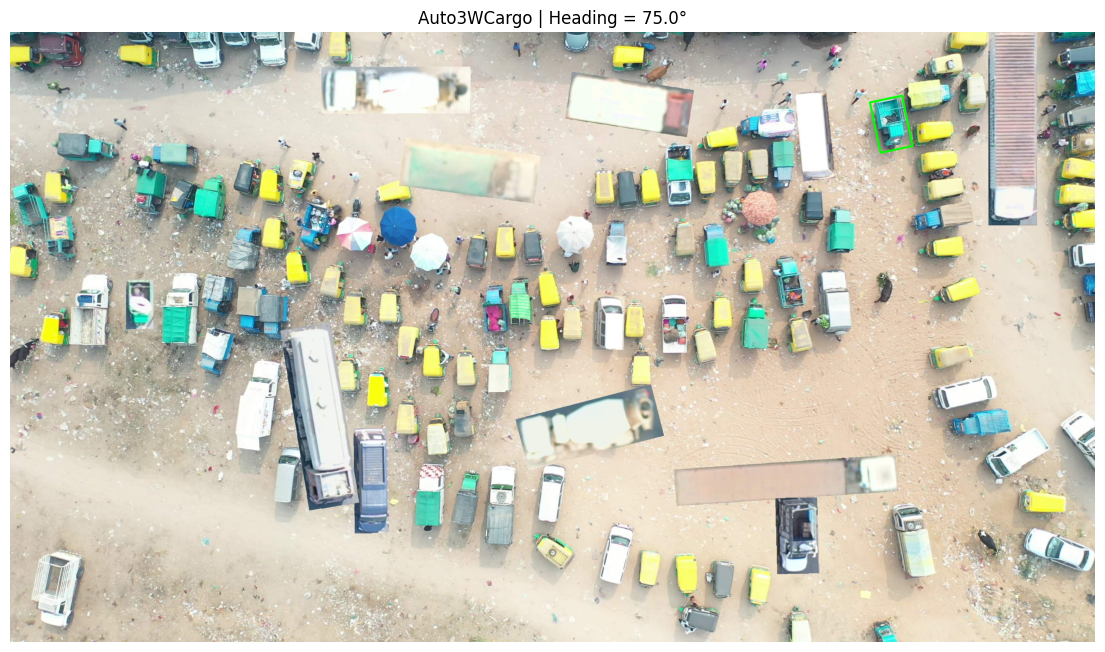

In [71]:
row = sample_df.iloc[0]

display_image = image.copy()

points = row["obb_points"].astype(
    np.int32
).reshape(
    (-1, 1, 2)
)

cv2.polylines(
    display_image,
    [points],
    isClosed=True,
    color=(0, 255, 0),
    thickness=5
)

display_image_rgb = cv2.cvtColor(
    display_image,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(14, 8))
plt.imshow(display_image_rgb)
plt.title(
    f"{row['class_name']} | "
    f"Heading = {row['heading']}°"
)
plt.axis("off")
plt.show()

## 13. Extracting the Vehicle Crop

The verified OBB is used to determine the spatial region containing the selected vehicle.

An axis-aligned crop is extracted around the OBB with a small amount of padding.

The purpose of this step is to create a vehicle-focused image for later image-processing experiments.

The vehicle is not rotated or geometrically rectified during extraction. Its original orientation in the image is preserved because orientation estimation will be performed in a later stage of the project.

In [72]:
def extract_crop(
    image,
    obb_points,
    padding=0.10
):

    h, w = image.shape[:2]

    pts = np.asarray(
        obb_points,
        dtype=np.float32
    )

    x_min = max(
        0,
        int(
            np.floor(
                pts[:, 0].min()
                - padding *
                (pts[:, 0].max() - pts[:, 0].min())
            )
        )
    )

    y_min = max(
        0,
        int(
            np.floor(
                pts[:, 1].min()
                - padding *
                (pts[:, 1].max() - pts[:, 1].min())
            )
        )
    )

    x_max = min(
        w,
        int(
            np.ceil(
                pts[:, 0].max()
                + padding *
                (pts[:, 0].max() - pts[:, 0].min())
            )
        )
    )

    y_max = min(
        h,
        int(
            np.ceil(
                pts[:, 1].max()
                + padding *
                (pts[:, 1].max() - pts[:, 1].min())
            )
        )
    )

    if x_max <= x_min or y_max <= y_min:
        return None

    return image[
        y_min:y_max,
        x_min:x_max
    ].copy()

Crop shape: (244, 183, 3)


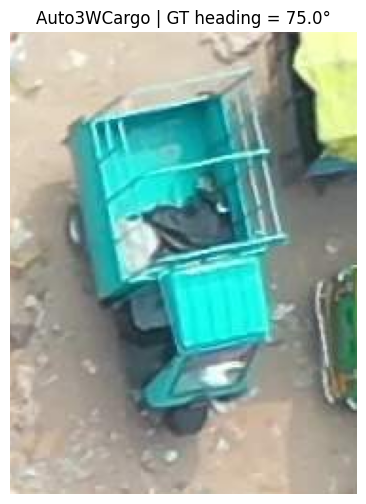

In [73]:
crop = extract_crop(
    image,
    row["obb_points"]
)

print(
    "Crop shape:",
    crop.shape
)

plt.figure(figsize=(6, 6))

plt.imshow(
    cv2.cvtColor(
        crop,
        cv2.COLOR_BGR2RGB
    )
)

plt.title(
    f"{row['class_name']} | "
    f"GT heading = {row['heading']}°"
)

plt.axis("off")
plt.show()

## 14. Methodological Note: Preserving the Original Vehicle Orientation

The extracted vehicle crop must retain the vehicle's original orientation.

The OBB annotation is used to identify and crop the vehicle, but the crop is not rotated to a horizontal reference position.

This is necessary because the subsequent project stage will estimate the vehicle orientation from the image content using conventional image-processing techniques.

Therefore:

**OBB → vehicle localization and crop extraction**

rather than:

**OBB → rotation correction → orientation estimation**

The original heading provided by the dataset is retained as ground-truth information for later comparison.

## 15. Preparing the Ground-Truth Orientation

The DRASHTI-HaOBB annotations provide the vehicle heading as an angle from 0° to 359°.

For this project, the heading is converted into the required 0°–90° orientation representation.

The original heading is retained, while the converted orientation is stored separately.

This allows the project to preserve the original dataset information while also creating the representation required for subsequent orientation-estimation evaluation.

In [74]:
def heading_to_orientation(
    heading
):

    theta = heading % 180

    if theta > 90:
        theta = 180 - theta

    return theta

In [75]:
for angle in [
    0, 30, 90,
    120, 180,
    225, 270,
    315
]:

    print(
        angle,
        "->",
        heading_to_orientation(angle)
    )

0 -> 0
30 -> 30
90 -> 90
120 -> 60
180 -> 0
225 -> 45
270 -> 90
315 -> 45


## 16. Applying the Dataset Preparation Pipeline to the Selected Vehicles

After the single-image verification is successful, the same procedure can be applied to the selected Week-2 vehicle samples.

For each selected vehicle, the pipeline performs the following operations:

**Annotation → Image Matching → Image Reading → OBB-Based Crop Extraction → Metadata Storage**

The stored metadata includes the vehicle class, difficulty level, original heading, converted ground-truth orientation, and crop dimensions.

These outputs form the dataset-preparation stage that will be used for the orientation-estimation experiments.


In [76]:
# ============================================
# CELL 1: SELECT 10 VEHICLES
# ============================================

ten_df = sample_df.head(10).copy()

print("Selected 10 vehicles:")
display(
    ten_df[
        [
            "image_stem",
            "vehicle_id",
            "class_name",
            "difficulty",
            "heading"
        ]
    ]
)

Selected 10 vehicles:


,image_stem,vehicle_id,class_name,difficulty,heading
0,fajh_DDXI_sVyD,103,Auto3WCargo,0,75.0
1,w8fp_m2WO_Ehux,3,Auto3WCargo,0,90.0
2,hW19_22e2_Ikt0,5,Auto3WCargo,0,173.0
3,pYWE_TnGD_nElC,36,Auto3WCargo,0,80.0
4,lv6a_dp9T_xWho,27,Auto3WCargo,0,94.0
5,OaRn_LjEv_37zf,53,Auto3WCargo,0,347.1
6,Yrne_u19R_I0V5,45,Auto3WCargo,0,274.0
7,4b3m_Gv8b_e30r,54,Auto3WCargo,0,270.0
8,7xQC_Xodc_PVRI,63,Auto3WCargo,0,347.1
9,u7ym_to7b_z4i6,71,Auto3WCargo,0,350.0


In [77]:
# ============================================
# CELL 2: EXTRACT 10 VEHICLE CROPS
# ============================================

import os
from pathlib import Path
import cv2
import numpy as np

TEN_CROP_DIR = Path("/content/week2_10_crops")
TEN_CROP_DIR.mkdir(
    parents=True,
    exist_ok=True
)

ten_results = []

for _, row in ten_df.iterrows():

    image_stem = row["image_stem"]

    # Check that image exists in train.zip
    if image_stem not in image_lookup:
        print(
            f"Image not found in train.zip: {image_stem}"
        )
        continue

    # Get image member from ZIP
    image_member = image_lookup[image_stem]

    # Read image
    raw = train_zip.read(image_member)

    image_array = np.frombuffer(
        raw,
        dtype=np.uint8
    )

    image = cv2.imdecode(
        image_array,
        cv2.IMREAD_COLOR
    )

    if image is None:
        print(
            f"Could not decode image: {image_stem}"
        )
        continue

    # Extract vehicle crop
    crop = extract_crop(
        image,
        row["obb_points"]
    )

    if crop is None:
        print(
            f"Could not extract crop: {image_stem}"
        )
        continue

    # Unique name
    vehicle_uid = (
        f"{image_stem}_"
        f"vehicle_{int(row['vehicle_id'])}"
    )

    crop_path = (
        TEN_CROP_DIR /
        f"{vehicle_uid}.jpg"
    )

    # Save crop
    success = cv2.imwrite(
        str(crop_path),
        crop
    )

    if not success:
        print(
            f"Could not save crop: {crop_path}"
        )
        continue

    # Convert GT heading to 0-90 orientation
    gt_orientation = heading_to_orientation(
        row["heading"]
    )

    ten_results.append({
        "vehicle_uid": vehicle_uid,
        "image_stem": image_stem,
        "vehicle_id": int(row["vehicle_id"]),
        "class_id": int(row["class_id"]),
        "class_name": row["class_name"],
        "difficulty": int(row["difficulty"]),
        "gt_heading": float(row["heading"]),
        "gt_orientation": float(gt_orientation),
        "crop_width": crop.shape[1],
        "crop_height": crop.shape[0],
        "crop_path": str(crop_path)
    })


ten_results_df = pd.DataFrame(
    ten_results
)

print(
    f"\nSuccessfully extracted "
    f"{len(ten_results_df)} / 10 vehicles."
)

display(ten_results_df)


Successfully extracted 10 / 10 vehicles.


,vehicle_uid,image_stem,vehicle_id,class_id,class_name,difficulty,gt_heading,gt_orientation,crop_width,crop_height,crop_path
0,fajh_DDXI_sVyD_vehicle_103,fajh_DDXI_sVyD,103,0,Auto3WCargo,0,75.0,75.0,183,244,/content/week2_10_crops/fajh_DDXI_sVyD_vehicle...
1,w8fp_m2WO_Ehux_vehicle_3,w8fp_m2WO_Ehux,3,0,Auto3WCargo,0,90.0,90.0,72,130,/content/week2_10_crops/w8fp_m2WO_Ehux_vehicle...
2,hW19_22e2_Ikt0_vehicle_5,hW19_22e2_Ikt0,5,0,Auto3WCargo,0,173.0,7.0,166,79,/content/week2_10_crops/hW19_22e2_Ikt0_vehicle...
3,pYWE_TnGD_nElC_vehicle_36,pYWE_TnGD_nElC,36,0,Auto3WCargo,0,80.0,80.0,132,175,/content/week2_10_crops/pYWE_TnGD_nElC_vehicle...
4,lv6a_dp9T_xWho_vehicle_27,lv6a_dp9T_xWho,27,0,Auto3WCargo,0,94.0,86.0,113,197,/content/week2_10_crops/lv6a_dp9T_xWho_vehicle...
5,OaRn_LjEv_37zf_vehicle_53,OaRn_LjEv_37zf,53,0,Auto3WCargo,0,347.1,12.9,129,84,/content/week2_10_crops/OaRn_LjEv_37zf_vehicle...
6,Yrne_u19R_I0V5_vehicle_45,Yrne_u19R_I0V5,45,0,Auto3WCargo,0,274.0,86.0,227,322,/content/week2_10_crops/Yrne_u19R_I0V5_vehicle...
7,4b3m_Gv8b_e30r_vehicle_54,4b3m_Gv8b_e30r,54,0,Auto3WCargo,0,270.0,90.0,103,204,/content/week2_10_crops/4b3m_Gv8b_e30r_vehicle...
8,7xQC_Xodc_PVRI_vehicle_63,7xQC_Xodc_PVRI,63,0,Auto3WCargo,0,347.1,12.9,130,84,/content/week2_10_crops/7xQC_Xodc_PVRI_vehicle...
9,u7ym_to7b_z4i6_vehicle_71,u7ym_to7b_z4i6,71,0,Auto3WCargo,0,350.0,10.0,124,79,/content/week2_10_crops/u7ym_to7b_z4i6_vehicle...


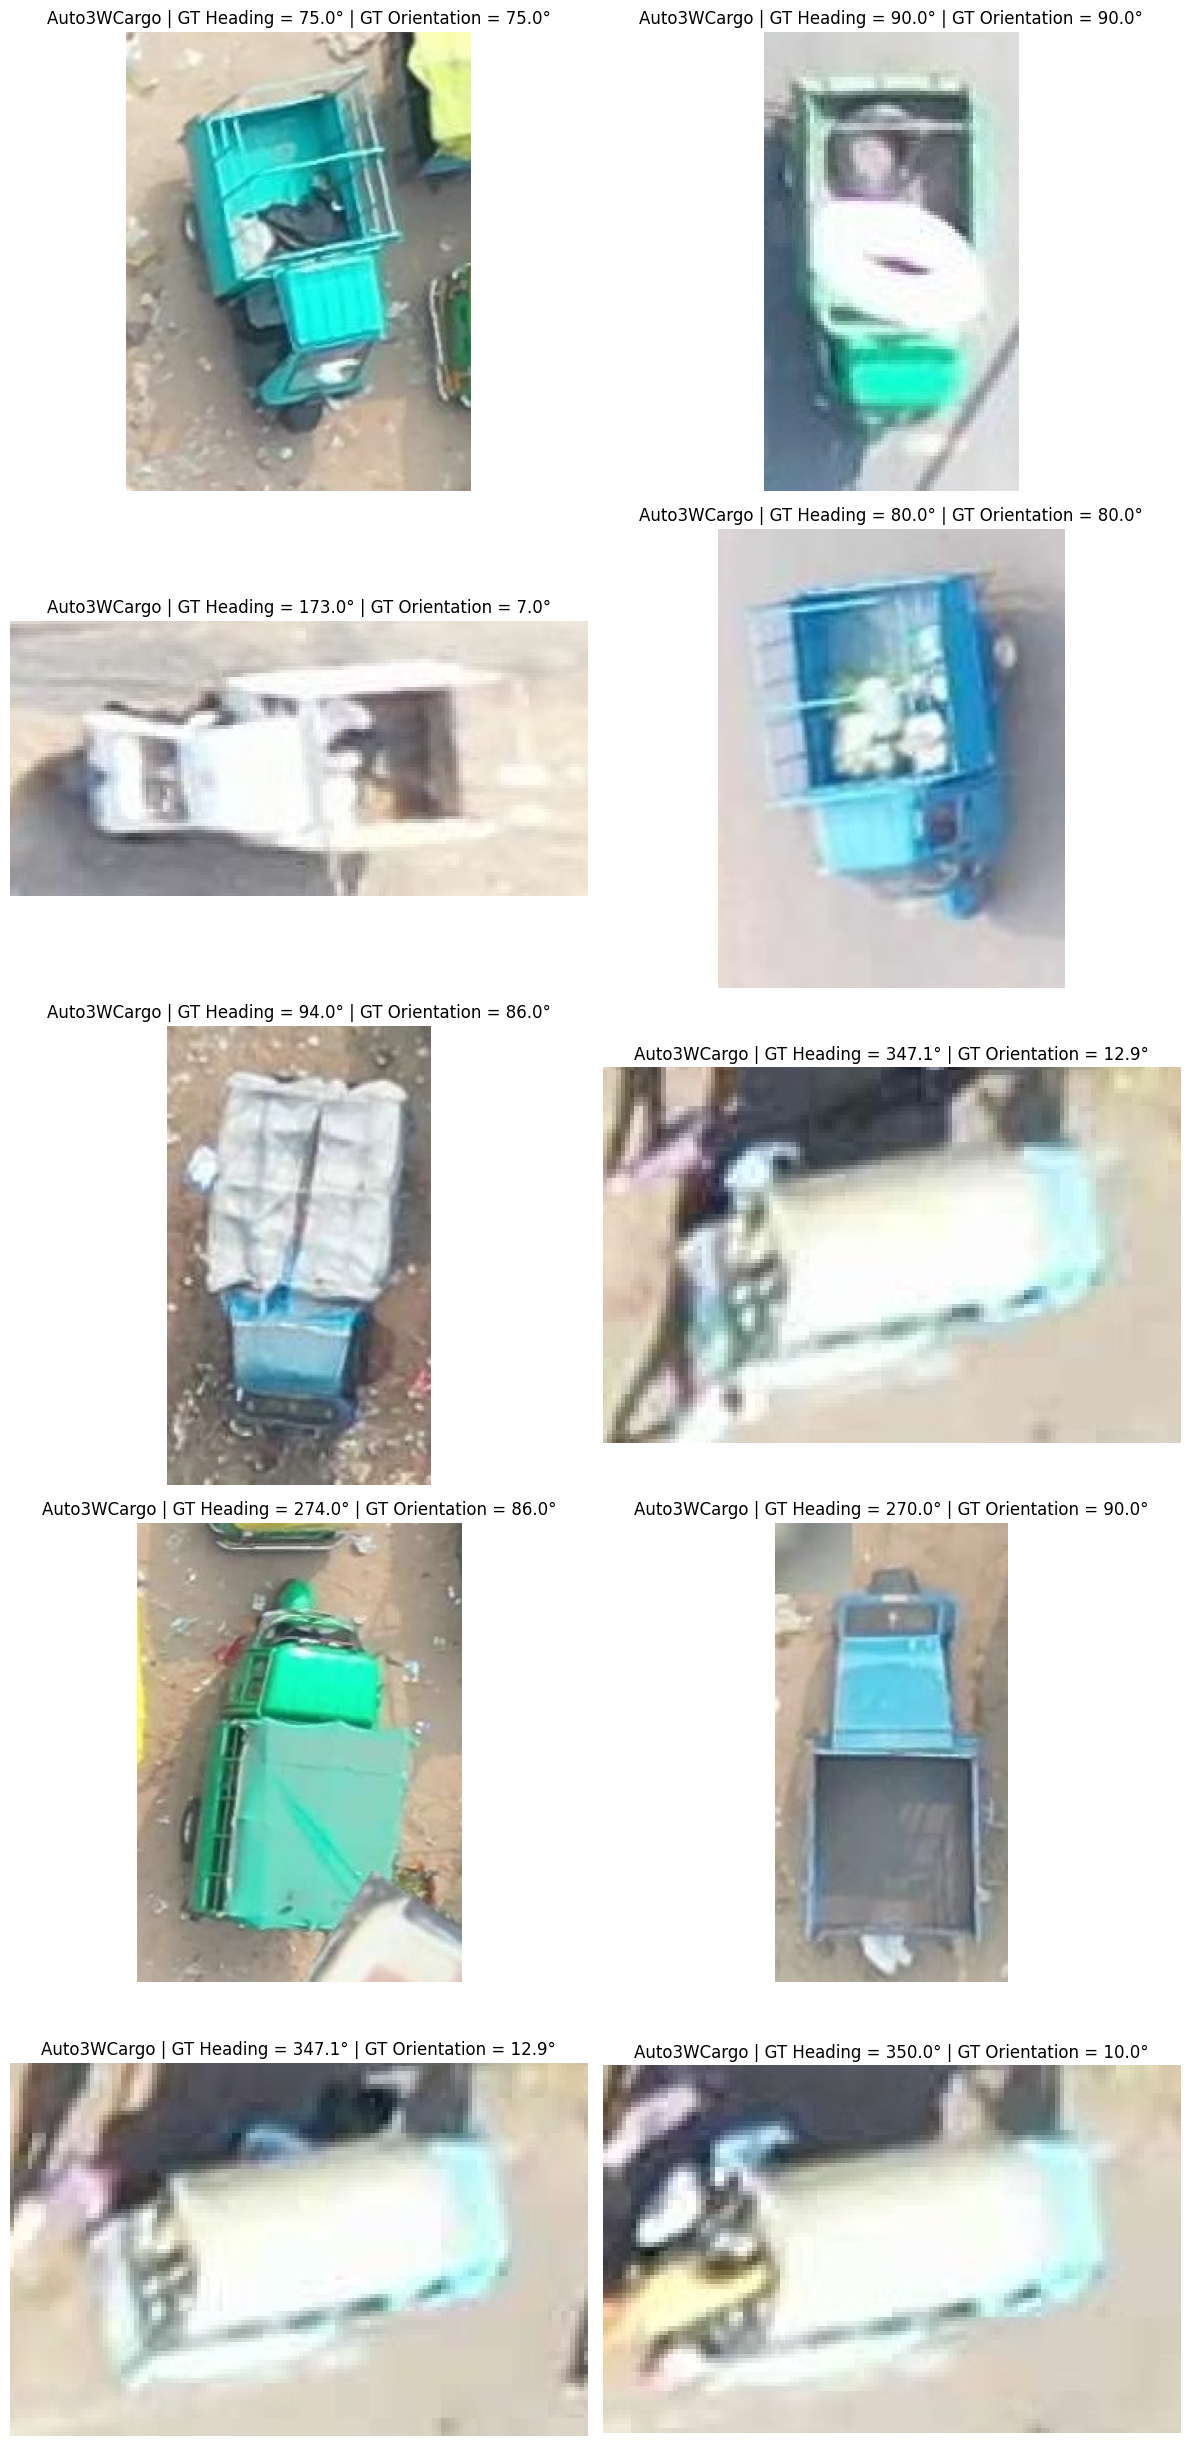

Saved grid: /content/week2_10_crops/10_vehicle_crops.png


In [78]:
# ============================================
# CELL 3: DISPLAY ALL 10 CROPS
# ============================================

n = len(ten_results_df)

cols = 2
rows = math.ceil(n / cols)

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(12, 5 * rows)
)

axes = np.array(axes).reshape(-1)

for ax, (_, row) in zip(
    axes,
    ten_results_df.iterrows()
):

    crop = cv2.imread(
        row["crop_path"]
    )

    crop_rgb = cv2.cvtColor(
        crop,
        cv2.COLOR_BGR2RGB
    )

    ax.imshow(crop_rgb)

    ax.set_title(
        f"{row['class_name']} | "
        f"GT Heading = {row['gt_heading']:.1f}° | "
        f"GT Orientation = {row['gt_orientation']:.1f}°"
    )

    ax.axis("off")


# Hide unused axes
for ax in axes[len(ten_results_df):]:
    ax.axis("off")

plt.tight_layout()

ten_crop_grid_path = (
    TEN_CROP_DIR /
    "10_vehicle_crops.png"
)

plt.savefig(
    ten_crop_grid_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved grid:",
    ten_crop_grid_path
)

In [79]:
# ============================================
# CELL 4: SAVE 10-VEHICLE METADATA
# ============================================

TEN_TABLE_DIR = Path(
    "/content/week2_10_results"
)

TEN_TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

ten_metadata_path = (
    TEN_TABLE_DIR /
    "10_vehicle_metadata.csv"
)

ten_results_df.to_csv(
    ten_metadata_path,
    index=False
)

print(
    "Saved:",
    ten_metadata_path
)

Saved: /content/week2_10_results/10_vehicle_metadata.csv


In [80]:
# ============================================
# SAVE WEEK-2 RESULTS PERMANENTLY TO DRIVE
# ============================================

from pathlib import Path
import shutil

# Your Drive project folder
DRIVE_PROJECT = Path(
    "/content/drive/MyDrive/ECE501_DRASHTI/Week2_Results"
)

# Create the required folders
DRIVE_PROJECT.mkdir(
    parents=True,
    exist_ok=True
)

DRIVE_CROPS = DRIVE_PROJECT / "10_vehicle_crops"
DRIVE_TABLES = DRIVE_PROJECT / "tables"
DRIVE_IMAGES = DRIVE_PROJECT / "images"

for folder in [
    DRIVE_CROPS,
    DRIVE_TABLES,
    DRIVE_IMAGES
]:
    folder.mkdir(
        parents=True,
        exist_ok=True
    )


# --------------------------------------------
# 1. Copy 10 vehicle crops
# --------------------------------------------

LOCAL_CROPS = Path(
    "/content/week2_10_crops"
)

if LOCAL_CROPS.exists():

    for file in LOCAL_CROPS.iterdir():

        if file.is_file():

            shutil.copy2(
                file,
                DRIVE_CROPS / file.name
            )

    print(
        "10 vehicle crops copied."
    )

else:
    print(
        "WARNING: Local crop folder not found."
    )


# --------------------------------------------
# 2. Copy metadata CSV
# --------------------------------------------

LOCAL_TABLES = Path(
    "/content/week2_10_results"
)

metadata_file = (
    LOCAL_TABLES /
    "10_vehicle_metadata.csv"
)

if metadata_file.exists():

    shutil.copy2(
        metadata_file,
        DRIVE_TABLES /
        metadata_file.name
    )

    print(
        "Metadata CSV copied."
    )

else:
    print(
        "WARNING: Metadata CSV not found."
    )


# --------------------------------------------
# 3. Copy crop grid image if it exists
# --------------------------------------------

crop_grid = (
    Path("/content/week2_10_crops")
    /
    "10_vehicle_crops.png"
)

if crop_grid.exists():

    shutil.copy2(
        crop_grid,
        DRIVE_IMAGES /
        crop_grid.name
    )

    print(
        "Crop grid copied."
    )


print("\nDONE.")
print(
    "Drive location:"
)
print(DRIVE_PROJECT)

10 vehicle crops copied.
Metadata CSV copied.
Crop grid copied.

DONE.
Drive location:
/content/drive/MyDrive/ECE501_DRASHTI/Week2_Results


Found:
Image: 4b3m_Gv8b_e30r
Vehicle ID: 54
Class: Auto3WCargo
GT Heading: 270.0
GT Orientation: 90.0


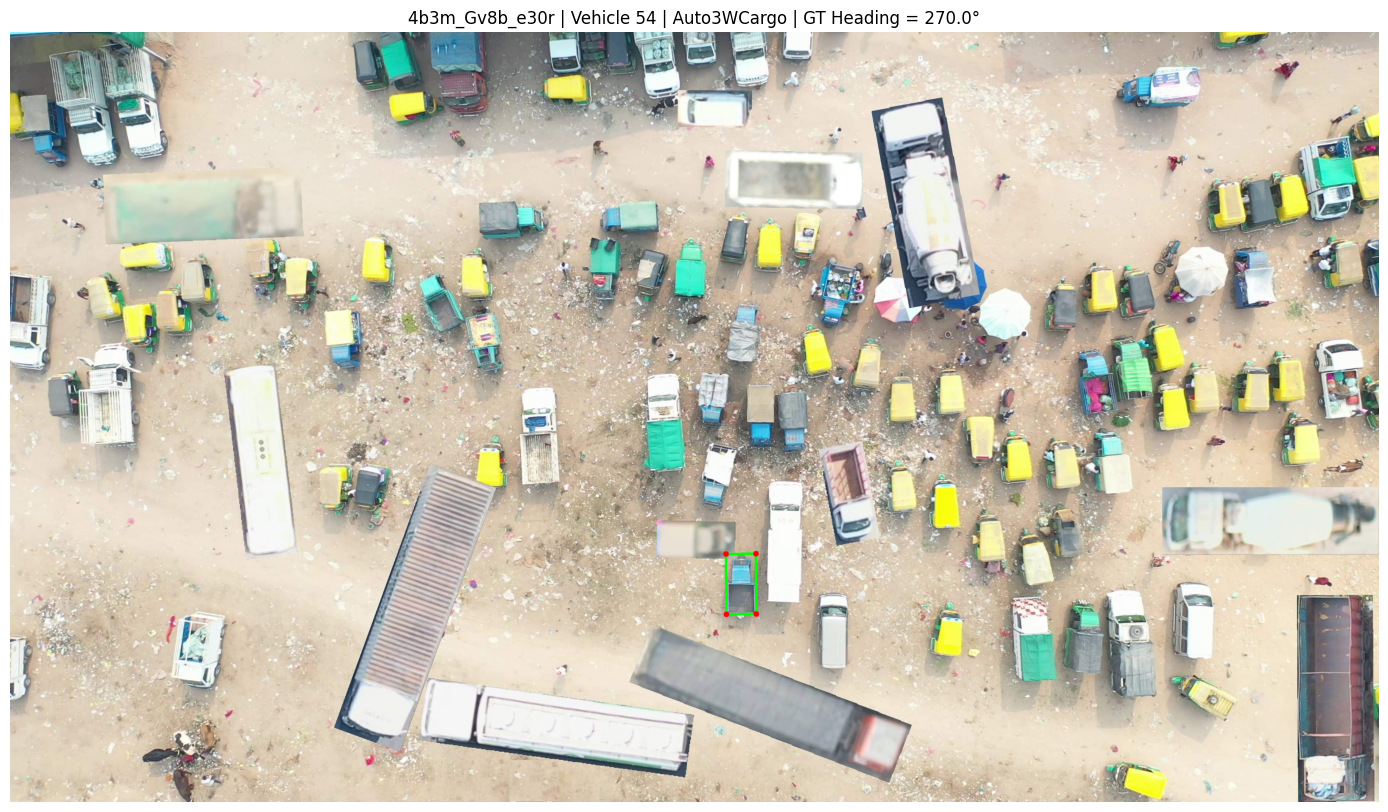


Saved:
/content/drive/MyDrive/ECE501_DRASHTI/Week2_Results/4b3m_Gv8b_e30r_vehicle_54_OBB.jpg


In [87]:
# ============================================================
# DRAW OBB FOR ONLY:
# 4b3m_Gv8b_e30r_vehicle_54
# ============================================================

from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

TARGET_STEM = "4b3m_Gv8b_e30r"
TARGET_VEHICLE_ID = 54

# ------------------------------------------------------------
# Find the exact vehicle from the SAME 10 already selected
# ------------------------------------------------------------
target_row = ten_results_df[
    (ten_results_df["image_stem"] == TARGET_STEM) &
    (ten_results_df["vehicle_id"] == TARGET_VEHICLE_ID)
]

if target_row.empty:
    raise ValueError(
        "This exact vehicle was not found in ten_results_df."
    )

target_row = target_row.iloc[0]

print("Found:")
print("Image:", target_row["image_stem"])
print("Vehicle ID:", target_row["vehicle_id"])
print("Class:", target_row["class_name"])
print("GT Heading:", target_row["gt_heading"])
print("GT Orientation:", target_row["gt_orientation"])

# ------------------------------------------------------------
# Find original image in train.zip
# ------------------------------------------------------------
if TARGET_STEM not in image_lookup:
    raise ValueError(
        f"{TARGET_STEM} not found in train.zip."
    )

image_member = image_lookup[TARGET_STEM]

# Read original image
raw = train_zip.read(image_member)

image_array = np.frombuffer(
    raw,
    dtype=np.uint8
)

image = cv2.imdecode(
    image_array,
    cv2.IMREAD_COLOR
)

if image is None:
    raise ValueError(
        "Could not decode original image."
    )

# ------------------------------------------------------------
# Get EXACT OBB from the corresponding annotation
# ------------------------------------------------------------
annotation_row = annotations_df[
    (annotations_df["image_stem"] == TARGET_STEM) &
    (annotations_df["vehicle_id"] == TARGET_VEHICLE_ID)
]

if annotation_row.empty:
    raise ValueError(
        "Exact annotation for vehicle 54 was not found."
    )

annotation_row = annotation_row.iloc[0]

obb_points = np.asarray(
    annotation_row["obb_points"],
    dtype=np.int32
)

polygon = obb_points.reshape(
    (-1, 1, 2)
)

# ------------------------------------------------------------
# Draw ONLY this vehicle's OBB
# ------------------------------------------------------------
output = image.copy()

cv2.polylines(
    output,
    [polygon],
    isClosed=True,
    color=(0, 255, 0),
    thickness=6
)

# Draw corner points
for i, point in enumerate(obb_points):

    x = int(point[0])
    y = int(point[1])

    cv2.circle(
        output,
        (x, y),
        8,
        (0, 0, 255),
        -1
    )

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
OUTPUT_DIR = Path(
    "/content/drive/MyDrive/ECE501_DRASHTI/Week2_Results"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

output_path = (
    OUTPUT_DIR /
    "4b3m_Gv8b_e30r_vehicle_54_OBB.jpg"
)

cv2.imwrite(
    str(output_path),
    output
)

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------
plt.figure(figsize=(18, 10))

plt.imshow(
    cv2.cvtColor(
        output,
        cv2.COLOR_BGR2RGB
    )
)

plt.title(
    f"{TARGET_STEM} | "
    f"Vehicle 54 | "
    f"{target_row['class_name']} | "
    f"GT Heading = {target_row['gt_heading']:.1f}°"
)

plt.axis("off")
plt.show()

print("\nSaved:")
print(output_path)